In [76]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [75]:
import kagglehub
path = kagglehub.dataset_download("mohansacharya/graduate-admissions")

100%|██████████| 9.64k/9.64k [00:00<00:00, 20.3MB/s]

Extracting files...


In [78]:
df = pd.read_csv(os.path.join(path,"Admission_Predict_Ver1.1.csv"))

In [79]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [80]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [81]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.drop(columns=['Serial No.'],inplace=True)

In [87]:
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]

In [88]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [89]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()

X_train_s=minmax.fit_transform(X_train)
X_test_s=minmax.transform(X_test)

In [99]:
model=Sequential()

model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(7,activation='relu'))
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [100]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [102]:
hist = model.fit(X_train_s,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.7747 - val_loss: 0.7709
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6559 - val_loss: 0.6678
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5766 - val_loss: 0.5991
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5242 - val_loss: 0.5554
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4901 - val_loss: 0.5256
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4668 - val_loss: 0.5042
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4483 - val_loss: 0.4852
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4317 - val_loss: 0.4675
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4156 - val_loss: 0.4495
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3990 - val_loss: 0.4307
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3812 - val_loss: 0.4100
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - lo

In [103]:
y_pred = model.predict(X_test_s)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [104]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7387738111091143

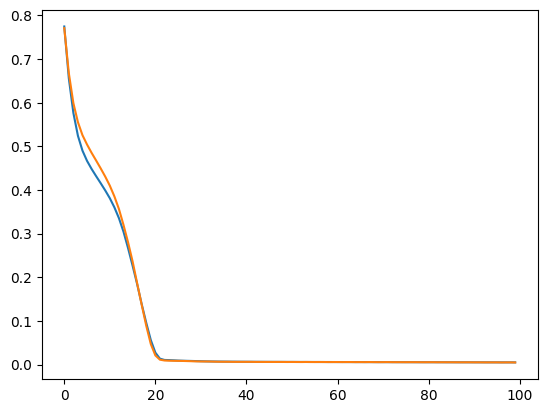

In [105]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])